# Live Webcam Depth with Depth Anything V2

This notebook reads frames from your webcam and runs **Depth Anything V2** on each one. It shows the camera and the depth map together in a live window, either side by side or blended.

How the live window works:
- **Smooth video:** the camera runs at its full 30 FPS. Depth is computed in a background thread and shown with each frame as soon as it's ready.
- **Fast inference:** the model runs on **OpenVINO** (Intel's inference engine). On this laptop that's about 2× faster than PyTorch on CPU.
- **Steady depth:** depth is smoothed over time in areas that aren't moving, so it doesn't flicker.
- **Sharp edges:** the depth map is upsampled with a **guided filter**, which uses the camera image to keep depth edges lined up with real object edges.

## How to run

**One-time setup** (already done on this machine. Repeat it only on a fresh clone):

```bash
cd eye-in-the-sky
python -m venv .venv
.venv/bin/pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
.venv/bin/pip install opencv-python matplotlib ipykernel openvino
.venv/bin/python -m ipykernel install --user --name eye-in-the-sky --display-name "Python (eye-in-the-sky)"
git clone https://github.com/DepthAnything/Depth-Anything-V2
mkdir -p Depth-Anything-V2/checkpoints
curl -L -o Depth-Anything-V2/checkpoints/depth_anything_v2_vits.pth \
  "https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth?download=true"
```

(Arch blocks system-wide `pip install`, which is why everything goes in `.venv`. The repo's `gradio` requirement is only for its web demo and is not needed here.)

**Every time:**

1. In VS Code, click **Select Kernel** (top right) → *Jupyter Kernel* → **Python (eye-in-the-sky)**.
2. Run cells 1–4 in order.
   - The first run of cell 2 converts the model to OpenVINO format, which takes a few seconds, and saves it to `models/`. Later runs load the saved copy.
   - Cell 4 shows one webcam frame and its depth map inline as a sanity check.
3. Run cell 5. A separate window called **Depth Anything V2** opens. Click it to give it focus, then use the keys:
   - `q` or `Esc`: quit (the background threads stop and the camera is released)
   - `m`: switch between side-by-side and blended views
   - `+` / `-`: change blend strength
   - `t`: turn temporal smoothing on/off
   - `e`: turn edge refinement (guided filter) on/off
   - `s`: save a snapshot PNG to `snapshots/`
4. While cell 5 runs it blocks the kernel. Quit with `q` before running other cells.

The on-screen text shows two rates. **view FPS** is how fast the window updates (about 30). **depth FPS** is how often a new depth map arrives. In blended view, the depth lags the camera image by about one depth frame.

In [15]:
# Cell 1: config + imports
import os, sys, time, threading, warnings
os.environ.setdefault('QT_QPA_PLATFORM', 'xcb')  # OpenCV's Qt has no Wayland plugin; use XWayland

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_DIR = 'Depth-Anything-V2'  # cloned repo, relative to this notebook
ENCODER = 'vits'                # 'vits' (Small), 'vitb' (Base), 'vitl' (Large); needs the matching checkpoint
INPUT_SIZE = 252                # model input height (rounded to a multiple of 14). Lower = faster, higher = more detail
BACKEND = 'openvino'            # 'openvino' (faster on Intel CPUs) or 'torch'
CAMERA_INDEX = 0                # /dev/video0
FRAME_W, FRAME_H = 640, 480
COLORMAP = cv2.COLORMAP_INFERNO

# Temporal smoothing: how much of the previous depth to keep where the scene is still (0 = off, 0.9 = very smooth)
DEPTH_SMOOTHING = 0.6
MOTION_THRESH = 20              # grey-level change (0-255) at which a pixel counts as fully "moving"

# Edge refinement: guided filter that snaps depth edges to edges in the camera image
REFINE_EDGES = True
GUIDED_RADIUS = 4               # neighbourhood size in pixels
GUIDED_EPS = 1e-4               # smaller = follows image edges more closely (but copies more texture)

sys.path.insert(0, REPO_DIR)
from depth_anything_v2.dpt import DepthAnythingV2

# Fixed model input size with the camera's aspect ratio; both sides must be multiples of 14
MODEL_H = round(INPUT_SIZE / 14) * 14
MODEL_W = round(INPUT_SIZE * FRAME_W / FRAME_H / 14) * 14

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch, 'xpu') and torch.xpu.is_available():
    DEVICE = 'xpu'  # Intel Arc (needs the XPU build of torch)
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
    torch.set_num_threads(os.cpu_count())
print(f'torch {torch.__version__} | OpenCV {cv2.__version__} | torch device: {DEVICE} | model input {MODEL_W}x{MODEL_H}')

torch 2.14.1+cpu | OpenCV 5.0.0 | torch device: cpu | model input 336x252


In [16]:
# Cell 2: load the model (+ convert to OpenVINO)
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64,  'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
}
ckpt = os.path.join(REPO_DIR, 'checkpoints', f'depth_anything_v2_{ENCODER}.pth')

model = DepthAnythingV2(**model_configs[ENCODER])
model.load_state_dict(torch.load(ckpt, map_location='cpu'))
model = model.to(DEVICE).eval()
print(f'Loaded {ckpt}')

MEAN = np.array([0.485, 0.456, 0.406], np.float32)
STD = np.array([0.229, 0.224, 0.225], np.float32)

def preprocess(frame_bgr):
    # BGR uint8 frame -> normalized 1x3xHxW float32 array at the model's fixed input size
    rgb = cv2.cvtColor(cv2.resize(frame_bgr, (MODEL_W, MODEL_H), interpolation=cv2.INTER_AREA), cv2.COLOR_BGR2RGB)
    x = (rgb.astype(np.float32) / 255.0 - MEAN) / STD
    return np.ascontiguousarray(x.transpose(2, 0, 1)[None])

@torch.inference_mode()
def torch_depth(x):
    return model(torch.from_numpy(x).to(DEVICE))[0].float().cpu().numpy()

ov_model = None
if BACKEND == 'openvino':
    try:
        import openvino as ov
        core = ov.Core()
        ov_path = f'models/da2_{ENCODER}_{MODEL_W}x{MODEL_H}.xml'
        if os.path.exists(ov_path):
            ov_ir = core.read_model(ov_path)
        else:
            print('Converting to OpenVINO (first run only, a few seconds)...')
            with torch.no_grad(), warnings.catch_warnings():
                warnings.simplefilter('ignore')  # tracing warnings from the repo's shape asserts are harmless
                ov_ir = ov.convert_model(model.cpu(), example_input=torch.zeros(1, 3, MODEL_H, MODEL_W))
            model.to(DEVICE)
            os.makedirs('models', exist_ok=True)
            ov.save_model(ov_ir, ov_path)
            print(f'Saved {ov_path}')
        ov_model = core.compile_model(ov_ir, 'CPU', {'PERFORMANCE_HINT': 'LATENCY'})
    except Exception as e:
        print(f'OpenVINO unavailable ({e!r}), falling back to torch')

def estimate_depth(frame_bgr):
    # Low-resolution relative inverse depth (bigger = closer), MODEL_H x MODEL_W
    x = preprocess(frame_bgr)
    return ov_model(x)[0][0] if ov_model is not None else torch_depth(x)

# Quick benchmark + check that OpenVINO matches torch
x = preprocess(np.random.randint(0, 255, (FRAME_H, FRAME_W, 3), np.uint8))
def bench(fn, n=5):
    fn(x); t = time.time()
    for _ in range(n): out = fn(x)
    return (time.time() - t) / n * 1000, out
t_ms, ref = bench(torch_depth)
print(f'torch:    {t_ms:5.0f} ms/frame')
if ov_model is not None:
    o_ms, out = bench(lambda x: ov_model(x)[0][0])
    corr = np.corrcoef(out.ravel(), ref.ravel())[0, 1]
    print(f'openvino: {o_ms:5.0f} ms/frame  ({t_ms / o_ms:.1f}x faster, output correlation {corr:.5f})')
print('Using', 'openvino' if ov_model is not None else f'torch ({DEVICE})')

Loaded Depth-Anything-V2/checkpoints/depth_anything_v2_vits.pth
torch:      106 ms/frame
openvino:    64 ms/frame  (1.7x faster, output correlation 0.99999)
Using openvino


In [17]:
# Cell 3: webcam + depth post-processing + background threads
def open_camera():
    cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_V4L2)
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_W)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_H)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)  # keep latency low: always grab the newest frame
    if not cap.isOpened():
        raise RuntimeError(f'Could not open camera {CAMERA_INDEX}. Is another app using it?')
    return cap

def normalize_depth(depth):
    # Relative depth has an arbitrary scale per frame, so map the 2nd-98th percentile to 0-1
    lo, hi = np.percentile(depth, (2, 98))
    return (depth - lo) / max(hi - lo, 1e-6)

class DepthStabilizer:
    # Motion-aware temporal smoothing: still areas are averaged over frames (no flicker),
    # areas where the camera image changed take the new depth immediately (no ghosting)
    def __init__(self, smoothing=DEPTH_SMOOTHING, motion_thresh=MOTION_THRESH):
        self.smoothing, self.motion_thresh = smoothing, motion_thresh
        self.prev = self.prev_gray = None

    def __call__(self, depth, frame, enabled=True):
        d = normalize_depth(depth).astype(np.float32)
        gray = cv2.cvtColor(cv2.resize(frame, (d.shape[1], d.shape[0]), interpolation=cv2.INTER_AREA),
                            cv2.COLOR_BGR2GRAY).astype(np.float32)
        if enabled and self.prev is not None:
            motion = np.clip(np.abs(gray - self.prev_gray) / self.motion_thresh, 0, 1)
            motion = cv2.GaussianBlur(motion, (0, 0), 2)
            a = 1 - self.smoothing
            d = motion * d + (1 - motion) * (a * d + (1 - a) * self.prev)
        self.prev, self.prev_gray = d, gray
        return d

def guided_upsample(depth_lr, frame, radius=GUIDED_RADIUS, eps=GUIDED_EPS):
    # Upsample to frame size, then guided filter (He et al.) with the grey camera frame as guide
    h, w = frame.shape[:2]
    p = cv2.resize(depth_lr, (w, h), interpolation=cv2.INTER_LINEAR)
    I = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    box = lambda m: cv2.boxFilter(m, -1, (2 * radius + 1, 2 * radius + 1))
    mean_I, mean_p = box(I), box(p)
    a = (box(I * p) - mean_I * mean_p) / (box(I * I) - mean_I * mean_I + eps)
    b = mean_p - a * mean_I
    return box(a) * I + box(b)

def plain_upsample(depth_lr, frame):
    return cv2.resize(depth_lr, (frame.shape[1], frame.shape[0]), interpolation=cv2.INTER_LINEAR)

class DepthColorizer:
    # Maps depth to colours using a smoothed min/max so the colours don't pulse between frames
    def __init__(self, momentum=0.9):
        self.momentum, self.lo, self.hi = momentum, None, None

    def __call__(self, depth):
        lo, hi = np.percentile(depth[::4, ::4], (2, 98))
        if self.lo is None:
            self.lo, self.hi = lo, hi
        else:
            self.lo = self.momentum * self.lo + (1 - self.momentum) * lo
            self.hi = self.momentum * self.hi + (1 - self.momentum) * hi
        norm = np.clip((depth - self.lo) / max(self.hi - self.lo, 1e-6), 0, 1)
        return cv2.applyColorMap((norm * 255).astype(np.uint8), COLORMAP)

def fuse(frame, depth_color, mode, alpha):
    if mode == 'blend':
        return cv2.addWeighted(frame, 1 - alpha, depth_color, alpha, 0)
    return np.hstack([frame, depth_color])

class LiveDepth:
    # Two background threads: one keeps the newest camera frame, the other turns the newest frame into a coloured
    # depth map. The display loop reads both without waiting, so the video stays at camera speed.
    def __init__(self, cap):
        self.cap = cap
        self.smooth, self.refine = DEPTH_SMOOTHING > 0, REFINE_EDGES
        self.stabilizer, self.colorize = DepthStabilizer(), DepthColorizer()
        self.lock, self.stopped = threading.Lock(), threading.Event()
        self.frame, self.frame_id, self.depth_color, self.depth_fps, self.error = None, 0, None, 0.0, None
        self.threads = [threading.Thread(target=f, daemon=True) for f in (self._capture_loop, self._depth_loop)]

    def start(self):
        for t in self.threads:
            t.start()
        return self

    def stop(self):
        self.stopped.set()
        for t in self.threads:
            t.join(timeout=5)

    def latest(self):
        with self.lock:
            return self.frame, self.frame_id, self.depth_color

    def _capture_loop(self):
        while not self.stopped.is_set():
            ok, frame = self.cap.read()
            if not ok:
                self.error = RuntimeError('Lost camera frame')
                self.stopped.set()
                break
            with self.lock:
                self.frame, self.frame_id = frame, self.frame_id + 1

    def _depth_loop(self):
        last_id, last_t = 0, time.time()
        try:
            while not self.stopped.is_set():
                frame, frame_id, _ = self.latest()
                if frame is None or frame_id == last_id:
                    time.sleep(0.002)
                    continue
                last_id = frame_id
                depth = self.stabilizer(estimate_depth(frame), frame, enabled=self.smooth)
                depth = guided_upsample(depth, frame) if self.refine else plain_upsample(depth, frame)
                depth_color = self.colorize(depth)
                now = time.time()
                self.depth_fps = 0.9 * self.depth_fps + 0.1 / (now - last_t) if self.depth_fps else 1 / (now - last_t)
                last_t = now
                with self.lock:
                    self.depth_color = depth_color
        except Exception as e:
            self.error = e
            self.stopped.set()

Inference: 105 ms | edge refinement: 8 ms | model output (252, 336) -> (480, 640)


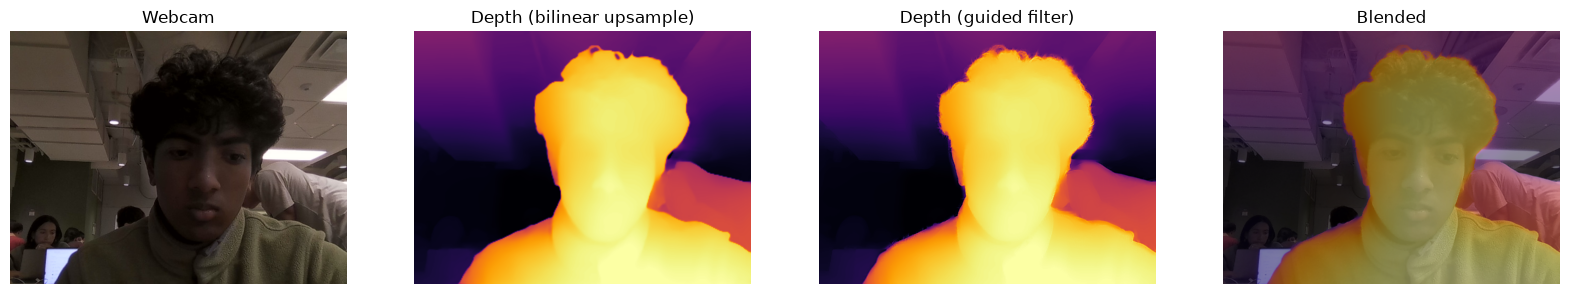

In [18]:
# Cell 4: sanity check, one frame shown inline
cap = open_camera()
for _ in range(5):  # let auto-exposure settle
    ok, frame = cap.read()
cap.release()
if not ok:
    raise RuntimeError('Camera opened but returned no frame')

t0 = time.time()
depth_lr = estimate_depth(frame)
t1 = time.time()
refined = guided_upsample(normalize_depth(depth_lr), frame)
t2 = time.time()
print(f'Inference: {(t1 - t0) * 1000:.0f} ms | edge refinement: {(t2 - t1) * 1000:.0f} ms | '
      f'model output {depth_lr.shape} -> {refined.shape}')

colorize = DepthColorizer()
raw_color = colorize(plain_upsample(normalize_depth(depth_lr), frame))
refined_color = DepthColorizer()(refined)
panels = [(frame, 'Webcam'), (raw_color, 'Depth (bilinear upsample)'),
          (refined_color, 'Depth (guided filter)'), (fuse(frame, refined_color, 'blend', 0.5), 'Blended')]
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, (img, title) in zip(ax, panels):
    a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); a.set_title(title); a.axis('off')
plt.show()

## Live depth

Running the next cell opens a separate window. Click the window, then press **`q`** to stop. `m` switches view, `+`/`-` change blend strength, `t`/`e` turn smoothing/edge refinement on and off, `s` saves a snapshot.

In [19]:
# Cell 5: live loop
WINDOW = 'Depth Anything V2'
mode, alpha = 'side', 0.5
os.makedirs('snapshots', exist_ok=True)

cap = open_camera()
live = LiveDepth(cap).start()
cv2.namedWindow(WINDOW, cv2.WINDOW_NORMAL)
view_fps, last_t, last_id = 0.0, time.time(), 0
try:
    while not live.stopped.is_set():
        frame, frame_id, depth_color = live.latest()
        if frame is not None and frame_id != last_id:  # only redraw when the camera has a new frame
            last_id = frame_id
            if depth_color is None:
                depth_color = np.zeros_like(frame)  # first depth map not ready yet
            view = fuse(frame, depth_color, mode, alpha)

            now = time.time()
            view_fps = 0.9 * view_fps + 0.1 / (now - last_t) if view_fps else 1 / (now - last_t)
            last_t = now
            label = (f'view {view_fps:4.1f} FPS | depth {live.depth_fps:4.1f} FPS | {ENCODER} @ {MODEL_W}x{MODEL_H} | '
                     f'smooth {"on" if live.smooth else "off"} | edges {"on" if live.refine else "off"}'
                     + (f' | a={alpha:.1f}' if mode == 'blend' else ''))
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(view, (5, 8), (15 + tw, 16 + th), (0, 0, 0), -1)
            cv2.putText(view, label, (10, 12 + th), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
            cv2.imshow(WINDOW, view)

        key = cv2.waitKey(5) & 0xFF
        if key in (ord('q'), 27):
            break
        elif key == ord('m'):
            mode = 'blend' if mode == 'side' else 'side'
        elif key in (ord('+'), ord('=')):
            alpha = min(alpha + 0.1, 1.0)
        elif key == ord('-'):
            alpha = max(alpha - 0.1, 0.0)
        elif key == ord('t'):
            live.smooth = not live.smooth
        elif key == ord('e'):
            live.refine = not live.refine
        elif key == ord('s') and last_id:
            path = f'snapshots/depth_{time.strftime("%Y%m%d_%H%M%S")}.png'
            cv2.imwrite(path, view); print('Saved', path)
        if cv2.getWindowProperty(WINDOW, cv2.WND_PROP_VISIBLE) < 1:  # window closed with the X button
            break
finally:
    live.stop()
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    print('Stopped and released camera')
if live.error:
    raise live.error

Stopped and released camera


## Tuning

All settings are in cell 1. Re-run cells 1–3 after changing them.

| Setting | What it does |
|---|---|
| `INPUT_SIZE` | Model resolution. Raising it gives more detail but slower depth: measured with OpenVINO on this laptop, 252 → ~52 ms (~16 depth FPS live), 308 → ~79 ms, 364 → ~122 ms, 420 → ~172 ms. Each new size is converted to OpenVINO once. |
| `BACKEND` | `'openvino'` (about 2× faster on this CPU) or `'torch'`. |
| `DEPTH_SMOOTHING` | 0–0.9. Higher = steadier depth in still areas. `0` turns it off. |
| `MOTION_THRESH` | Lower = more pixels count as "moving" and skip smoothing. Lower it if you see ghost trails, raise it if moving areas flicker. |
| `GUIDED_RADIUS` | Size of the neighbourhood (in pixels) the edge refinement looks at. Above ~8 it starts adding halos around your head. |
| `GUIDED_EPS` | Smaller = depth follows image edges more tightly, but can copy surface texture (e.g. patterns on a shirt) into the depth. |

## Troubleshooting

- **`No module named 'cv2'` / `'torch'` / `'openvino'`:** the wrong kernel is selected. Pick **Python (eye-in-the-sky)**.
- **`Could not open camera`:** another app (browser, Zoom) is using the webcam, or the previous loop didn't exit. Restart the kernel.
- **Image very bright / washed out:** the camera's backlight compensation is overexposing. Run `v4l2-ctl -d /dev/video0 -c backlight_compensation=0` in a terminal.
- **Window doesn't respond to keys:** click the window first. Keys go to the focused window, not the notebook.
- **Want more detail:** raise `INPUT_SIZE` (`364`, `518`), or try `vitb` after downloading `depth_anything_v2_vitb.pth` (non-commercial licence, much slower on CPU).
- **GPU (Intel Arc A370M):** run `sudo pacman -S intel-compute-runtime level-zero-loader`, then change `'CPU'` to `'GPU'` in `compile_model` in cell 2 to run the OpenVINO model on the Arc.
- **Depth values:** the output is *relative* inverse depth (brighter/hotter = closer), not metres.